Slope (m): 9.93893811582043
Intercept (b): 1.5615174230742535

Regression Equation:
Score = 9.9389 × Hours + 1.5615

Prediction for 7 Hours:
Predicted Score = 71.13

Mean Squared Error (MSE): 11.5598
Mean Absolute Error (MAE): 2.6075
Root Mean Squared Error (RMSE): 3.4000
R2 Score: 0.9813


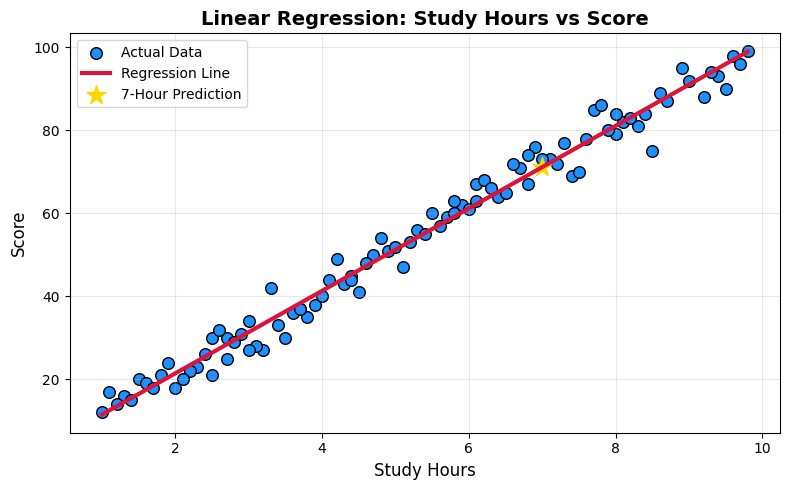

In [10]:
# Dataset source: Kaggle (himanshunakrani/student-study-hours); it contains study hours and corresponding student scores.

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("/kaggle/input/datasets/himanshunakrani/student-study-hours/score_updated.csv")

# Input and output
X = data["Hours"]
Y = data["Scores"]

# Loss function
def loss_function(m, b):
    y_pred = m * X + b
    error = Y - y_pred
    return (error ** 2).mean()


# Gradient Descent
def gradient_descent(m, b, learning_rate):
    dm = 0
    db = 0
    n = len(X)

    for i in range(n):
        x_val = X.iloc[i]
        y_val = Y.iloc[i]
        y_pred = m * x_val + b
        error = y_val - y_pred

        dm += -(2 / n) * x_val * error
        db += -(2 / n) * error

    m = m - learning_rate * dm
    b = b - learning_rate * db

    return m, b


# Initial values
m = 0
b = 0
learning_rate = 0.0001
epochs = 1000

loss_history = []


# Training
for epoch in range(epochs):
    m, b = gradient_descent(m, b, learning_rate)

    loss = loss_function(m, b)
    loss_history.append(loss)


# Final model
print("Slope (m):", m)
print("Intercept (b):", b)

print(f"\nRegression Equation:")
print(f"Score = {m:.4f} × Hours + {b:.4f}")


# Prediction for 7 Hours
hours = 7
predicted_score = m * hours + b

print(f"\nPrediction for {hours} Hours:")
print(f"Predicted Score = {predicted_score:.2f}")


# Prediction for all data
y_pred = m * X + b


# Error
error = Y - y_pred


# Mean Squared Error
mse = (error ** 2).mean()


# Mean Absolute Error
mae = abs(error).mean()


# Root Mean Squared Error
rmse = mse ** 0.5


# Print Error Metrics
print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


# R2 Score
ss_total = ((Y - Y.mean()) ** 2).sum()
ss_residual = ((Y - y_pred) ** 2).sum()

r2 = 1 - (ss_residual / ss_total)

print(f"R2 Score: {r2:.4f}")


# Regression Graph
plt.figure(figsize=(8, 5))


# Actual data
plt.scatter(
    X,
    Y,
    s=70,
    color="dodgerblue",
    edgecolor="black",
    label="Actual Data"
)


# Regression line
x_line = [X.min(), X.max()]
y_line = [m * x + b for x in x_line]

plt.plot(
    x_line,
    y_line,
    color="crimson",
    linewidth=3,
    label="Regression Line"
)


# Prediction point
plt.scatter(
    hours,
    predicted_score,
    s=200,
    color="gold",
    edgecolor="gold",
    marker="*",
    label="7-Hour Prediction"
)


# Labels and title
plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.title(
    "Linear Regression: Study Hours vs Score",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
